# Klasifikasi Berita dengan Vektor Skip-Gram + Naive Bayes

Data yang akan menjadi input berasal dari `detik_berita.csv`, yang merupakan
data hasil crawl pada website detik yang terdiri dari 100 berita finance dan
100 berita olahraga.

Data tersebut diuji dengan dua proses. Proses pertama hanya melakukan case
folding, yaitu mengubah seluruh huruf menjadi huruf kecil tanpa cleaning
tambahan. Proses kedua memakai preprocessing penuh, yaitu case folding,
pembuangan emoji, normalisasi bahasa tidak baku, dan penghapusan kata umum.
Kedua proses sama-sama mengambil fitur dengan skip-gram, lalu vektor
berita-nya dikirim ke Gaussian Naive Bayes dengan 5 lipatan untuk
dibandingkan.

## Import Library

Library yang dibutuhkan cuma lima. `numpy` dan `pandas` untuk menangani data
dan vektor, `gensim` untuk melatih Word2Vec skip-gram, `sklearn` untuk
klasifikasi Gaussian Naive Bayes beserta pembagian 5 lipatan dan metrik
evaluasinya, lalu `matplotlib` untuk menggrafik hasil perbandingan.

Catatan: `PCA` dari versi sebelumnya sudah dibuang, karena di sini PCA tidak
dipakai lagi.

In [1]:
import re
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print(f"gensim  {Word2Vec.__module__.split('.')[0]} siap")
print(f"sklearn GaussianNB siap")

pandas  3.0.5
numpy   2.5.3
gensim  gensim siap
sklearn GaussianNB siap


## Load Data

Data dibaca dari `detik_berita.csv` yang dipisah dengan titik koma. Kolom
`id` dan `isi_berita` dibersihkan dari spasi berlebih, berita kosong diganti
string kosong supaya tidak error saat diproses. Setelah itu dicek jumlah
berita, sebaran tiap tema, dan rata-rata panjang berita.

Dua hal yang perlu diperhatikan: jumlah berita harus genap 200, dan tiap tema
harus sama besar. Kalau tidak sama, nilai accuracy bisa condong ke kelas yang
lebih banyak.

In [2]:
df = pd.read_csv("detik_berita.csv", sep=";", dtype=str)
df.columns = [c.strip() for c in df.columns]
df["id"] = df["id"].str.strip()
df["isi_berita"] = df["isi_berita"].fillna("")

print(f"{len(df)} berita | kolom: {list(df.columns)}")
print(df["tema"].value_counts().to_string())
print(f"\nRata-rata panjang berita: {df['isi_berita'].str.len().mean():.0f} karakter")
df.head()

200 berita | kolom: ['id', 'isi_berita', 'tema']
tema
finance     100
olahraga    100

Rata-rata panjang berita: 2218 karakter


,id,isi_berita,tema
0,1,Harga emas Antam terus mengalami penurunan dan...,finance
1,2,"Perdana Menteri (PM) Singapura, Lawrence Wong,...",finance
2,3,Semua masyarakat akan memiliki rekening bank. ...,finance
3,4,"CEO Badan Pengelola Investasi (BPI) Danantara,...",finance
4,5,Jakarta - Kampoeng Mainan di Blok M Square men...,finance


## Dua Proses Preprocessing

Teks berita diproses dengan dua cara berbeda, dan keduanya nanti jadi dua
korpus terpisah untuk dilatih skip-gram.

- **Proses pertama** (`tokenisasi_a`): hanya case folding, lalu dipecah jadi
  token. Tanpa kamus, tanpa buang kata umum, tanpa buang tanda baca.
- **Proses kedua** (`tokenisasi_b`): case folding, buang emoji, perbaiki
  bahasa tidak baku pakai kamus, lalu buang kata umum.

Kamus bahasa tidak baku dan daftar kata umum diambil dari preprocessing
Tugas 2 supaya hasilnya konsisten. Kata diganti di tempatnya pakai `re.sub`,
bukan dirakit ulang dari daftar kata, supaya posisinya dalam kalimat tetap
terjaga.

Catatan penting: yang diuji di sini bukan modelnya, melainkan efek
preprocessing itu sendiri. Karena itu semua parameter skip-gram, Naive Bayes,
dan 5 lipatan dikunci sama di kedua proses.

In [3]:
KAMUS_TIDAK_BAKU = {
    "nggak": "tidak", "enggak": "tidak", "gak": "tidak", "kagak": "tidak",
    "udah": "sudah", "gitu": "begitu", "gini": "begini",
    "bikin": "membuat", "biarin": "biarkan", "cuma": "hanya",
    "aja": "saja", "tuh": "itu", "kayaknya": "sepertinya", "kayak": "seperti",
    "ngaco": "kacau", "banget": "sangat", "makin": "semakin",
    "dibilang": "dikatakan", "bilang": "berkata",
    "cuan": "untung", "karir": "karier",
    "ojol": "ojek", "detikers": "pembaca", "gede": "besar",
    "emang": "memang", "gimana": "bagaimana", "pakai": "memakai",
    "kalo": "kalau", "mesti": "harus", "dipindahin": "dipindahkan",
    "yg": "yang", "dgn": "dengan", "utk": "untuk", "spt": "seperti", "krn": "karena",
    "perkeonomian": "perekonomian", "pemeritah": "pemerintah", "menyetujul": "menyetujui",
    "sih": "", "kok": "", "deh": "", "dong": "", "lah": "", "toh": "", "loh": "", "mah": "",
    "kan": "", "nih": "",
}

KAMUS_ASING_SUBSTITUSI = {
    "import": "impor", "point": "poin", "tennis": "tenis",
    "elite": "elit", "standard": "standar",
}

KATA_ASING = {
    "a", "an", "and", "are", "as", "at", "be", "been", "but", "by", "can", "could",
    "do", "does", "did", "for", "from", "had", "has", "have", "he", "her", "his",
    "if", "in", "into", "is", "it", "its", "may", "might", "must", "not", "of", "on",
    "or", "she", "should", "so", "than", "that", "the", "their", "them", "there",
    "these", "they", "this", "those", "to", "was", "we", "were", "what", "when",
    "where", "which", "while", "who", "whom", "why", "will", "with", "would", "you",
    "your", "all", "any", "both", "each", "few", "more", "most", "other", "some",
    "such", "no", "own", "same", "too", "only", "just", "because", "until", "now",
    "very", "about", "after", "before", "between", "over", "under", "again", "further",
    "then", "once", "here", "men", "him", "us", "com", "www",
    "games", "champions", "league", "world", "race", "run", "set", "team", "start",
    "beach", "sport", "sports", "event", "fc", "super", "top", "pre", "center",
    "international", "approved", "online", "offline", "business", "price", "pricing",
    "market", "marketplace", "asset", "leveraging", "buy", "buyback", "corporate",
    "group", "location", "single", "streamlining", "commerce", "national", "investment",
    "artificial", "intelligence", "existing", "cost", "training", "tax", "village",
    "fame", "harmony", "marketing", "host", "buying", "panic", "tower", "fraud",
    "mission", "sprint", "tour", "time", "step", "running", "runner", "fun",
}

STOPWORDS_ID = {
    "yang", "dan", "di", "ke", "dari", "pada", "itu", "ini", "juga", "untuk",
    "dengan", "akan", "adalah", "ialah", "oleh", "karena", "agar", "sebagai",
    "para", "dalam", "serta", "atau", "masih", "sudah", "belum", "tidak",
    "bukan", "bisa", "dapat", "lebih", "saat", "ketika", "setelah", "sebelum",
    "selama", "melalui", "antara", "hingga", "kemudian", "lantas", "merupakan",
    "namun", "tetapi", "tapi", "terdapat", "ada", "adanya", "yaitu", "yakni",
    "terkait", "misalnya", "maupun", "seperti", "jika", "kalau", "maka", "harus",
    "hendak", "sangat", "paling", "semua", "setiap", "beberapa", "saya", "anda",
    "kami", "kita", "mereka", "dia", "ia", "kepada", "bagi", "pun",
    "saja", "mungkin", "lagi", "tersebut", "adapun", "beserta",
}

RE_EMOJI = re.compile(
    "[\U0001F000-\U0001FAFF\U00002600-\U000027BF\U0000FE00-\U0000FE0F"
    "\U0001F1E6-\U0001F1FF\U00002B00-\U00002BFF]+"
)
RE_KATA = re.compile(r"[a-z\u00e0-\u00ff]+")


def _normalisasi_kata(m):
    w = m.group()
    if len(w) < 2 or w in KATA_ASING:
        return ""
    return KAMUS_ASING_SUBSTITUSI.get(w, KAMUS_TIDAK_BAKU.get(w, w))


def tokenisasi_a(teks):
    # case folding saja, lalu dipecah jadi kata
    return RE_KATA.findall(teks.casefold())


def tokenisasi_b(teks):
    # case folding -> buang emoji -> normalisasi -> tokenisasi -> buang kata umum
    t = RE_EMOJI.sub(" ", teks.casefold())
    t = re.sub(r"[a-z\u00e0-\u00ff]+", _normalisasi_kata, t)
    token = [w for w in RE_KATA.findall(t) if len(w) > 1]
    return [w for w in token if w not in STOPWORDS_ID]


TOK = {"A": df["isi_berita"].apply(tokenisasi_a).tolist()}

# cek cepat: dua proses harus benar-benar berbeda
# kalimat ini sengaja memakai kata tidak baku ("nggak") dan kata umum
# ("di", "yang") supaya perbedaan kedua proses kelihatan jelas
contoh = "Harga emas Antam, nggak naik 50% di bursa, yang lagi panas \U0001F3C0"
print("proses A (case folding)    :", tokenisasi_a(contoh))
print("proses B (preprocessing)  :", tokenisasi_b(contoh))

proses A (case folding)    : ['harga', 'emas', 'antam', 'nggak', 'naik', 'di', 'bursa', 'yang', 'lagi', 'panas']
proses B (preprocessing)  : ['harga', 'emas', 'antam', 'naik', 'bursa', 'panas']


## Jalur A - Skip-Gram Tanpa Preprocessing

Pada proses ini teks berita dipakai apa adanya, hanya case folding, supaya
terlihat hasil skip-gram tanpa bantuan cleaning sama sekali.

**Melatih Word2Vec.** Tiap berita dipecah jadi daftar kata, lalu dibaca 50 kali
sambil menebak kata tetangga dalam radius 5 kata. Hasil akhirnya satu vektor
100 dimensi untuk tiap kata. Parameter `min_count=1` dipakai supaya tidak ada
kata yang dibuang, dan `sample=0` supaya kata yang sering muncul tidak
dikurangi.

**Menggabungkan kata jadi berita.** Word2Vec cuma menghasilkan vektor per kata,
sedangkan klasifikasi butuh vektor per berita. Karena tiap berita punya jumlah
kata berbeda-beda, vektor berita diambil sebagai rata-rata semua vektor kata
di dalamnya, sehingga panjangnya selalu 100 dimensi.

**Klasifikasi.** Modelnya Gaussian Naive Bayes, bukan Multinomial, karena vektor
skip-gram bisa bernilai negatif sedangkan Multinomial hanya menerima nilai tidak
negatif. Data dibagi 5 lipatan dengan `StratifiedKFold`, jadi tiap berita diuji
tepat satu kali dan jumlah kelas di tiap lipatan tetap seimbang. Keempat metrik
pakai `average="macro"` karena finance dan olahraga sama penting.

**Tabel A** berisi 6 baris: 5 lipatan plus baris rata-rata, dengan 7 kolom
metrik. Kolomnya perlu dibaca baris per baris, bukan cuma rata-ratanya - nilai
rata-rata yang tinggi tapi simpangan antar lipatan besar berarti hasilnya tidak
stabil, tergantung berita mana yang kebetulan masuk sebagai data uji.

Semua parameter di sini dikunci dan tidak diubah, supaya nanti bisa dibandingkan
langsung dengan Jalur B.

In [4]:
PARAM_SKIPGRAM = dict(
    vector_size=100,
    window=5,
    min_count=1,
    negative=5,
    sample=0,
    epochs=50,
    sg=1,
    seed=42,
    workers=1,
)

METRIK = ["Accuracy", "Precision", "Recall", "F1-Score"]


def jalankan_proses(token, nama_proses):
    # 1. latih Word2Vec skip-gram di atas seluruh korpus
    t0 = time.time()
    model = Word2Vec(sentences=token, **PARAM_SKIPGRAM)
    mv = model.wv
    total_token = sum(len(t) for t in token)

    # 2. vektor berita = rata-rata vektor kata
    X = np.array([np.mean([mv[w] for w in t if w in mv], axis=0) for t in token])

    # 3. klasifikasi Gaussian Naive Bayes dengan 5 lipatan
    y = df["tema"].to_numpy()
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    baris = []
    for i, (tr, te) in enumerate(skf.split(X, y), start=1):
        clf = GaussianNB().fit(X[tr], y[tr])
        pred = clf.predict(X[te])
        baris.append({
            "Proses": nama_proses,
            "Lipatan": i,
            "Accuracy": accuracy_score(y[te], pred),
            "Precision": precision_score(y[te], pred, average="macro", zero_division=0),
            "Recall": recall_score(y[te], pred, average="macro", zero_division=0),
            "F1-Score": f1_score(y[te], pred, average="macro", zero_division=0),
            "Vocabulary": len(mv),
        })

    tabel = pd.DataFrame(baris)
    rata = {"Proses": nama_proses, "Lipatan": "Rata-rata", "Vocabulary": len(mv)}
    for m in METRIK:
        rata[m] = tabel[m].mean()
    tabel = pd.concat([tabel, pd.DataFrame([rata])], ignore_index=True)

    print(f"{nama_proses}: {total_token} token | vocabulary {len(mv)} kata "
          f"| rata-rata {total_token / len(df):.0f} token/berita "
          f"| vektor berita {X.shape} | {time.time() - t0:.1f} detik")
    return tabel, model, X


tabel_a, model_a, X_a = jalankan_proses(TOK["A"], "A - case folding saja")
display(tabel_a.round(4))

A - case folding saja: 60357 token | vocabulary 7489 kata | rata-rata 302 token/berita | vektor berita (200, 100) | 16.6 detik


,Proses,Lipatan,Accuracy,Precision,Recall,F1-Score,Vocabulary
0,A - case folding saja,1,0.975,0.9762,0.975,0.9750,7489
1,A - case folding saja,2,0.975,0.9762,0.975,0.9750,7489
2,A - case folding saja,3,0.975,0.9762,0.975,0.9750,7489
3,A - case folding saja,4,0.925,0.9348,0.925,0.9246,7489
4,A - case folding saja,5,0.950,0.9545,0.950,0.9499,7489
5,A - case folding saja,Rata-rata,0.960,0.9636,0.960,0.9599,7489


## Jalur B - Skip-Gram Dengan Preprocessing

Sekarang teks berita dibersihkan dulu sebelum jadi token. Kamus bahasa tidak
baku dan daftar kata umum di atas dipakai di sini, tidak di Jalur A.

Semua parameter skip-gram, Naive Bayes, dan 5 lipatan **dikunci sama persis**
dengan Jalur A. Satu-satunya yang beda adalah teksnya. Ini penting, kalau
parameternya ikut beda, selisih akurasi nanti tidak bisa dikaitkan ke
preprocessing.

Perhatikan dua angka ini sebelum lanjut: jumlah token dan ukuran vocabulary.
Kalau preprocessing bekerja, vocabulary harus mengecil karena kata umum dan
bentuk tidak baku sudah dirapikan menjadi satu kata.

In [5]:
TOK["B"] = df["isi_berita"].apply(tokenisasi_b).tolist()

tabel_b, model_b, X_b = jalankan_proses(TOK["B"], "B - preprocessing penuh")
display(tabel_b.round(4))

B - preprocessing penuh: 44084 token | vocabulary 7266 kata | rata-rata 220 token/berita | vektor berita (200, 100) | 12.0 detik


,Proses,Lipatan,Accuracy,Precision,Recall,F1-Score,Vocabulary
0,B - preprocessing penuh,1,1.000,1.0000,1.000,1.0000,7266
1,B - preprocessing penuh,2,0.950,0.9545,0.950,0.9499,7266
2,B - preprocessing penuh,3,0.975,0.9762,0.975,0.9750,7266
3,B - preprocessing penuh,4,0.925,0.9348,0.925,0.9246,7266
4,B - preprocessing penuh,5,0.950,0.9545,0.950,0.9499,7266
5,B - preprocessing penuh,Rata-rata,0.960,0.9640,0.960,0.9599,7266


## Perbandingan A vs B

Tabel A dan Tabel B ditampilkan terpisah, masing-masing 5 lipatan plus baris
rata-rata. Dipisah supaya angka tiap proses bisa dibaca tanpa saling campur,
mengingat nanti keduanya digabung juga ke dalam satu diagram batang.

Kolom `Vocabulary` sengaja ikut ditampilkan, bukan cuma pelengkap. Jumlah kata
itu menjelaskan kenapa hasilnya beda: proses pertama menyimpan semua kata apa
adanya, termasuk kata umum dan bentuk tidak baku yang berdiri sendiri sebagai
kata sendiri.

In [6]:
print("Tabel A - case folding saja")
display(tabel_a.round(4))


Tabel A - case folding saja


,Proses,Lipatan,Accuracy,Precision,Recall,F1-Score,Vocabulary
0,A - case folding saja,1,0.975,0.9762,0.975,0.9750,7489
1,A - case folding saja,2,0.975,0.9762,0.975,0.9750,7489
2,A - case folding saja,3,0.975,0.9762,0.975,0.9750,7489
3,A - case folding saja,4,0.925,0.9348,0.925,0.9246,7489
4,A - case folding saja,5,0.950,0.9545,0.950,0.9499,7489
5,A - case folding saja,Rata-rata,0.960,0.9636,0.960,0.9599,7489


In [7]:
print("Tabel B - preprocessing penuh")
display(tabel_b.round(4))


Tabel B - preprocessing penuh


,Proses,Lipatan,Accuracy,Precision,Recall,F1-Score,Vocabulary
0,B - preprocessing penuh,1,1.000,1.0000,1.000,1.0000,7266
1,B - preprocessing penuh,2,0.950,0.9545,0.950,0.9499,7266
2,B - preprocessing penuh,3,0.975,0.9762,0.975,0.9750,7266
3,B - preprocessing penuh,4,0.925,0.9348,0.925,0.9246,7266
4,B - preprocessing penuh,5,0.950,0.9545,0.950,0.9499,7266
5,B - preprocessing penuh,Rata-rata,0.960,0.9640,0.960,0.9599,7266


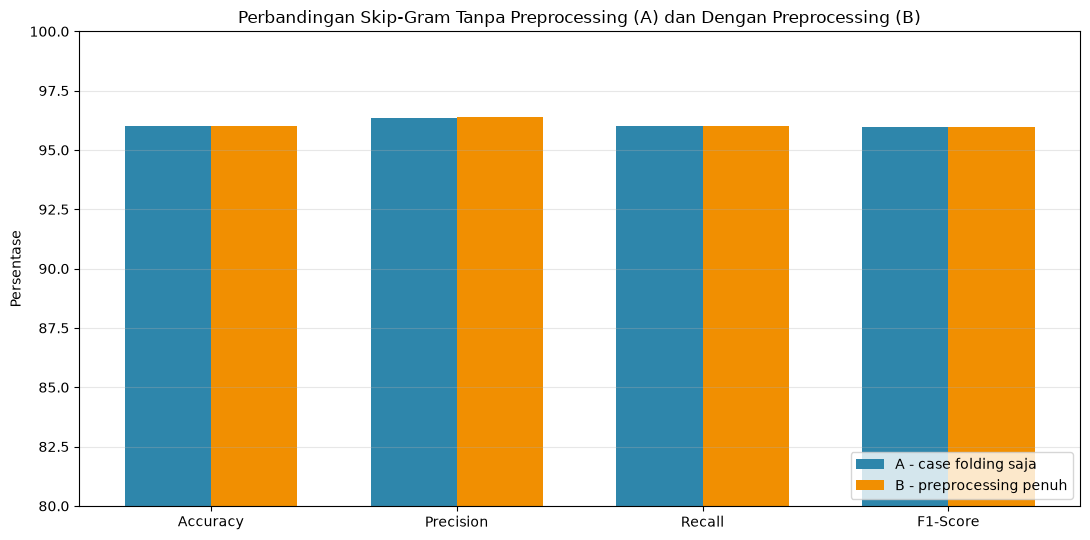

In [8]:
tabel_gabung = pd.concat([tabel_a, tabel_b], ignore_index=True)

rata = tabel_gabung[tabel_gabung["Lipatan"] == "Rata-rata"].set_index("Proses")

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(METRIK))
lebar = 0.35
warna = {"A - case folding saja": "#2E86AB", "B - preprocessing penuh": "#F18F01"}

for i, proses in enumerate(rata.index):
    nilai = [rata.loc[proses, m] * 100 for m in METRIK]
    ax.bar(x + (i - 0.5) * lebar, nilai, lebar, label=proses, color=warna[proses])

ax.set_xticks(x)
ax.set_xticklabels(METRIK)
ax.set_ylabel("Persentase")
ax.set_ylim(80, 100)
ax.set_title("Perbandingan Skip-Gram Tanpa Preprocessing (A) dan Dengan Preprocessing (B)")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [9]:
def tukar(nilai):
    """Bulatin ke 1 desimal, dan ubah -0.0 jadi 0.0."""
    n = round(nilai, 1)
    return 0.0 if n == 0 else n


print("Perbandingan rata-rata 5 lipatan:")
print(f"  A  case folding saja  : {rata.loc['A - case folding saja', 'Accuracy'] * 100:.1f} %")
print(f"  B  preprocessing penuh: {rata.loc['B - preprocessing penuh', 'Accuracy'] * 100:.1f} %")
print()
print("Selisih B - A per metrik:")
for m in METRIK:
    a = rata.loc["A - case folding saja", m] * 100
    b = rata.loc["B - preprocessing penuh", m] * 100
    print(f"  {m:<10} A {a:5.1f} %   B {b:5.1f} %   selisih {tukar(b - a):+.1f} poin")

selisih_acc = (rata.loc["B - preprocessing penuh", "Accuracy"]
               - rata.loc["A - case folding saja", "Accuracy"]) * 100
print()
print(f"Selisih akurasi B - A : {tukar(selisih_acc):+.1f} poin")
if abs(selisih_acc) < 0.05:
    print("Selisih nol. Preprocessing tidak mengubah rata-rata akurasi.")
elif selisih_acc > 0:
    print("Selisih positif. Preprocessing membantu.")
else:
    print("Selisih negatif. Preprocessing justru menurunkan hasil.")

# simpangan antar lipatan, untuk melihat mana yang lebih konsisten
print()
print("Konsistensi antar lipatan:")
for proses in rata.index:
    lipatan = tabel_gabung[
        (tabel_gabung["Proses"] == proses) & (tabel_gabung["Lipatan"] != "Rata-rata")
    ]["Accuracy"]
    print(f"  {proses:<22} {lipatan.min() * 100:.1f} - {lipatan.max() * 100:.1f} % "
          f"(simpangan {lipatan.std() * 100:.1f} poin)")

Perbandingan rata-rata 5 lipatan:
  A  case folding saja  : 96.0 %
  B  preprocessing penuh: 96.0 %

Selisih B - A per metrik:
  Accuracy   A  96.0 %   B  96.0 %   selisih +0.0 poin
  Precision  A  96.4 %   B  96.4 %   selisih +0.0 poin
  Recall     A  96.0 %   B  96.0 %   selisih +0.0 poin
  F1-Score   A  96.0 %   B  96.0 %   selisih +0.0 poin

Selisih akurasi B - A : +0.0 poin
Selisih nol. Preprocessing tidak mengubah rata-rata akurasi.

Konsistensi antar lipatan:
  A - case folding saja  92.5 - 97.5 % (simpangan 2.2 poin)
  B - preprocessing penuh 92.5 - 100.0 % (simpangan 2.9 poin)
